# Two-Layer Grid

In [32]:
using DifferentialEquations
using LightGraphs
using GraphRecipes
using Statistics
using LaTeXStrings
using Plots
using LinearAlgebra
using Plotly

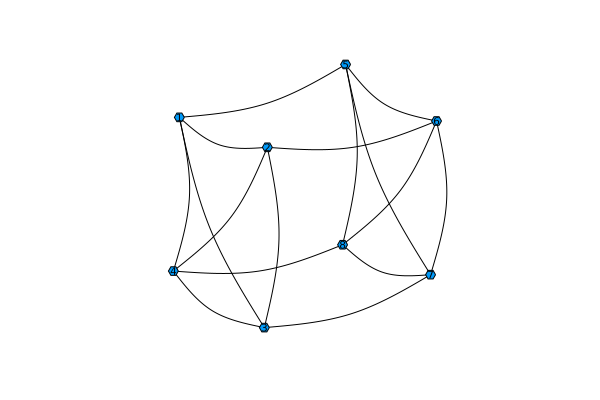

In [33]:
function gmake(n)
    g1=CompleteGraph(n)
    int=Int(nv(g1)/2)
    for i in 1:int
        for j in (int+1):Int(2*int)
            rem_edge!(g1,i,j)
        end
    add_edge!(g1,i,int+i)
    end
    return g1
end
graphplot(gmake(8),names=1:nv(gmake(8)))

In [3]:
function G_generate(C)
    U, Σ, V = svd(C)
    U*diagm(0 => sqrt.(Σ))*U'
end

G_generate (generic function with 1 method)

In [4]:
function r2N(sol,tf)
    N=length(sol[1:end,1])
    A=zeros(length(sol[1,1:end]))
    for i in 1:N
        A=A.+exp.(sol[i,1:end]*im)
    end
    return mean((1/N^2)*abs2.(A))
end

r2N (generic function with 1 method)

# Kuramoto Model with 1 Correlation Parameter

In [5]:
#Make G
function gmatrix1(n,ρ,σ)
    int=Int(n/2)
    C=ρ*ones(n,n)
    C[diagind(C)] .= 1
    for i in 1:int
        C[(int+1):end,i]=ρ*ones(int)
    end
    for i in (int+1):n
        C[1:int,i]=ρ*ones(int)
    end
    G=(σ/sqrt(2))*G_generate(C)
    return G
end

gmatrix1 (generic function with 1 method)

In [6]:
function soltnN(grid,w,k,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        for i in 1:n
            du[i]=w[i]+(k/n)*sum([sin(u[j]-u[i]) for j in 1:n])
        end
    end
    
    function g(du,u,p,t)
        du.=gmatrix1(n,ρ,σ)
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(n,n))
    sol=solve(prob,EM(),dt=0.001)
    return sol
end

soltnN (generic function with 1 method)

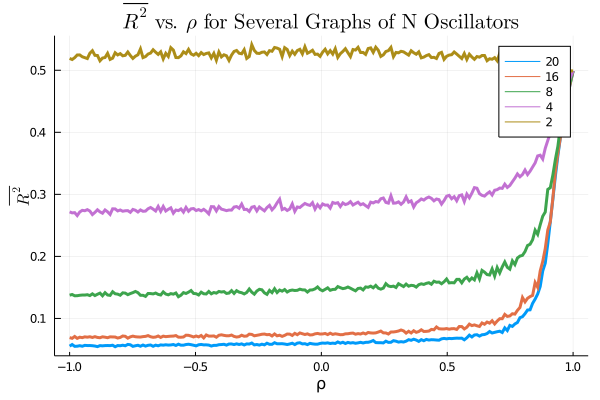

In [169]:
#R^2 vs rho plot
tf=5000.0
k=0.25
e(ρ)=r2N(gmake(2),soltnN(gmake(2),vcat(-(1/2)*ones(1),(1/2)*ones(1)),k,zeros(2),(0.0,tf),sqrt(2),ρ),tf)
f(ρ)=r2N(gmake(4),soltnN(gmake(4),vcat(-(1/2)*ones(2),(1/2)*ones(2)),k,zeros(4),(0.0,tf),sqrt(2),ρ),tf)
g(ρ)=r2N(gmake(8),soltnN(gmake(8),vcat(-(1/2)*ones(4),(1/2)*ones(4)),k,zeros(8),(0.0,tf),sqrt(2),ρ),tf)
h(ρ)=r2N(gmake(16),soltnN(gmake(16),vcat(-(1/2)*ones(8),(1/2)*ones(8)),k,zeros(16),(0.0,tf),sqrt(2),ρ),tf)
i(ρ)=r2N(gmake(20),soltnN(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),k,zeros(20),(0.0,tf),sqrt(2),ρ),tf)
ks=LinRange(-1,1,200)
edat4=e.(ks)
fdat4=f.(ks)
gdat4=g.(ks)
hdat4=h.(ks)
idat4=i.(ks)
Plots.plot(ks,[idat4,hdat4,gdat4,fdat4,edat4],title= L"\overline{R^2} \textrm{ vs. ρ for Several Graphs of N Oscillators}",label=["20" "16" "8" "4" "2"],xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

In [7]:
function RsqrTheory(ρ,k,σ)
    ϵ=sqrt(σ^2*(1-ρ))
    return (1/2)+2*k*ϵ^2*(k^2+8*ϵ^4+2)/((k^2-4)^2+16*(k^2+5)*ϵ^4+64*ϵ^8)
end

RsqrTheory (generic function with 1 method)

In [34]:
#k=0.2 σ=0.1
tf=5000.0
k=0.2
σ=0.1/sqrt(2)
e(ρ)=r2N(soltnN(gmake(2),vcat(-(1/2)*ones(1),(1/2)*ones(1)),k,zeros(2),(0.0,tf),σ,ρ),tf)
edat5=e.(ks);

In [35]:
f(ρ)=RsqrTheory(ρ,k,σ/sqrt(2))
ks=LinRange(-1,1,50)

50-element LinRange{Float64}:
 -1.0,-0.959184,-0.918367,-0.877551,-0.836735,…,0.877551,0.918367,0.959184,1.0

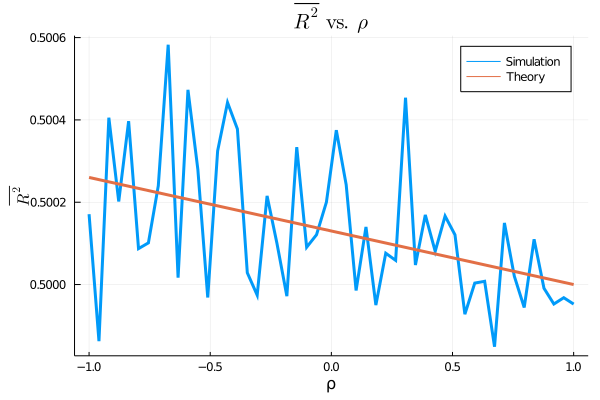

In [36]:
Plots.plot(ks,[edat5,f],title= L"\overline{R^2} \textrm{ vs. ρ}",label=["Simulation" "Theory"],xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

# Swing Equation

In [93]:
function swingsoltnN(grid,D,B,P,M,u0,tspan,σ,ρ)
    E=incidence_matrix(grid;oriented=true)
    n=nv(grid)
    
    function f(du,u,p,t)
        du[1:n]=u[n+1:2n]
        du[n+1:2n] = (-D.*u[n+1:2n] - E*((B/n).*sin.(E'*u[1:n])) + P)./M 
    end
    
    function g(du,u,p,t)
       du=gmake1(n,ρ,σ)
    end
    
    prob=SDEProblem(f,g,u0,tspan,noise_rate_prototype=zeros(2n,2n))
    sol=solve(prob,ImplicitEM(),dt=0.04)
    return sol
end

swingsoltnN (generic function with 1 method)

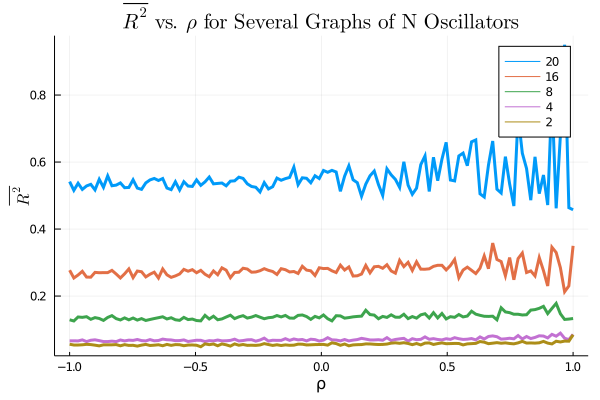

In [94]:
tf=2500.0
function Ds(n)
    D=ones(nv(gmake(n)))
    return D
end
function Ms(n)
    M=ones(nv(gmake(n)))
    return M
end
    
function Ps(n)
    P=rand(nv(gmake(n)))
    P=P.-mean(P)
    return P
end
function u0s(n)
    u0=zeros(2*nv(gmake(n)))
    return u0
end
B=0.25
e(ρ)=r2N(gmake(2),swingsoltnN(gmake(2),Ds(2),B*ones(ne(gmake(2))),Ps(2),Ms(2),u0s(2),(0.0,tf),sqrt(2),ρ),(0.0,tf))
f(ρ)=r2N(gmake(4),swingsoltnN(gmake(4),Ds(4),B*ones(ne(gmake(4))),Ps(4),Ms(4),u0s(4),(0.0,tf),sqrt(2),ρ),(0.0,tf))
g(ρ)=r2N(gmake(8),swingsoltnN(gmake(8),Ds(8),B*ones(ne(gmake(8))),Ps(8),Ms(8),u0s(8),(0.0,tf),sqrt(2),ρ),(0.0,tf))
h(ρ)=r2N(gmake(16),swingsoltnN(gmake(16),Ds(16),B*ones(ne(gmake(16))),Ps(16),Ms(16),u0s(16),(0.0,tf),sqrt(2),ρ),(0.0,tf))
i(ρ)=r2N(gmake(20),swingsoltnN(gmake(20),Ds(20),B*ones(ne(gmake(20))),Ps(20),Ms(20),u0s(20),(0.0,tf),sqrt(2),ρ),(0.0,tf))
ks=LinRange(-1,1,120)
edat3=e.(ks)
fdat3=f.(ks)
gdat3=g.(ks)
hdat3=h.(ks)
idat3=i.(ks)
Plots.plot(ks,[edat3,fdat3,gdat3,hdat3,idat3],title=L"\overline{R^2} \textrm{ vs. ρ for Several Graphs of N Oscillators}",label=["20" "16" "8" "4" "2"],xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

In [ ]:
g1=gmake(2)
using Plotly
tf=2000.0
D=ones(nv(g1))
M=ones(nv(g1))
P=rand(nv(g1))
P=P.-mean(P)
u0=zeros(2*nv(g1))
size=40
xs2 = [string(i/size) for i = -size:size]
ys2 = [string(2*i/size) for i = 1:size]
z2 = float((1:size) * reshape(1:(2*size+1), 1, :))
for b in 1:size
    for j in 1:(2*size+1)
        z2[b,j]=r2N(swingsoltnN(g1,D,(2*b/size)*ones(ne(g1)),P,M,u0,(0.0,tf),sqrt(2),(j-size-1)/size),(0.0,tf))
    end
end
Plots.heatmap(xs2,ys2,z2,aspect_ratio=1)

In [71]:
#Run Tonight
using Plotly
Plotly.signin("trs3","n3lr1fNnHZO2eMj4FUhv")
Plotly.set_credentials_file(Dict("username"=>"trs3","api_key"=>"n3lr1fNnHZO2eMj4FUhv"))
my_plot = Plotly.plot([Plotly.heatmap(x=xs2,y=ys2,z=z2')])
post(my_plot)


LoadError: InterruptException:

In [77]:
#Data sigma sqrt 2 Swing
tf=25000.0
k=0.25
e(ρ)=r2N(gmake(2),swingsoltnN(gmake(2),vcat(-(1/2)*ones(1),(1/2)*ones(1)),k,zeros(2),(0.0,tf),sqrt(2),ρ),(0.0,tf))
f(ρ)=r2N(gmake(2),swingsoltnN(gmake(4),vcat(-(1/2)*ones(2),(1/2)*ones(2)),k,zeros(4),(0.0,tf),sqrt(2),ρ),(0.0,tf))
g(ρ)=r2N(gmake(2),swingsoltnN(gmake(8),vcat(-(1/2)*ones(4),(1/2)*ones(4)),k,zeros(8),(0.0,tf),sqrt(2),ρ),(0.0,tf))
h(ρ)=r2N(gmake(2),swingsoltnN(gmake(16),vcat(-(1/2)*ones(8),(1/2)*ones(8)),k,zeros(16),(0.0,tf),sqrt(2),ρ),(0.0,tf))
i(ρ)=r2N(gmake(2),swingsoltnN(gmake(20),vcat(-(1/2)*ones(10),(1/2)*ones(10)),k,zeros(20),(0.0,tf),sqrt(2),ρ),(0.0,tf))
ks=LinRange(-1,1,500)
edat2=e.(ks)
fdat2=f.(ks)
gdat2=g.(ks)
hdat2=h.(ks)
idat2=i.(ks)

LoadError: MethodError: no method matching swingsoltnN(::SimpleGraph{Int64}, ::Array{Float64,1}, ::Float64, ::Array{Float64,1}, ::Tuple{Float64,Float64}, ::Float64, ::Float64)
Closest candidates are:
  swingsoltnN(::Any, ::Any, ::Any, ::Any, ::Any, ::Any, ::Any, !Matched::Any, !Matched::Any) at In[34]:1

In [78]:
Plots.plot(ks,[idat2,hdat2,gdat2,fdat2,edat2],title= L"\overline{R^2} \textrm{ vs. ρ for Several Graphs of N Oscillators}",label=["20" "16" "8" "4" "2"],xlabel="ρ",ylabel=L"\overline{R^2}",width=3)

LoadError: UndefVarError: idat2 not defined